In [2]:
from transformers import pipeline

classifier  = pipeline("sentiment-analysis")

classifier ("I am waiting for you")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9983296990394592}]

this pipeline groups together three steps: preprocessing, passing the inputs through the model, and postprocessing:

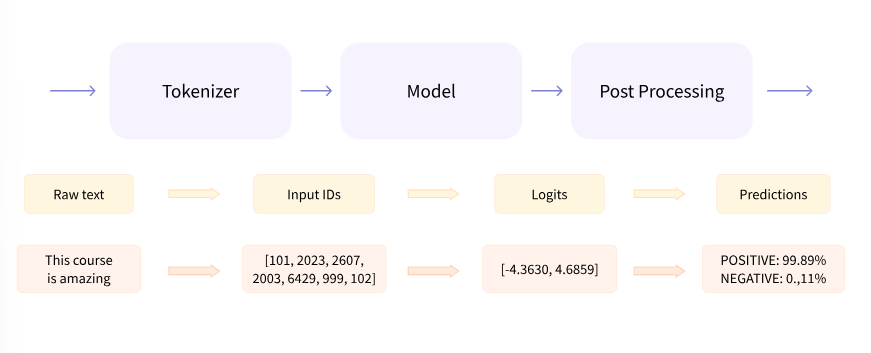

**Preprocessing with a tokenizer**
Like other neural networks, Transformer models can’t process raw text directly, so the first step of our pipeline is to convert the text inputs into numbers that the model can make sense of. To do this we use a tokenizer, which will be responsible for:

* Splitting the input into words, subwords, or symbols (like punctuation) that are called tokens
* Mapping each token to an integer
* Adding additional inputs that may be useful to the model

All this preprocessing needs to be done in exactly the same way as when the model was pretrained, so we first need to download that information from the Model Hub. To do this, we use the AutoTokenizer class and its from_pretrained() method. Using the checkpoint name of our model, it will automatically fetch the data associated with the model’s tokenizer and cache it (so it’s only downloaded the first time you run the code below).

Since the default checkpoint of the sentiment-analysis pipeline is distilbert-base-uncased-finetuned-sst-2-english (you can see its model card here), we run the following:

In [4]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Once we have the tokenizer, we can directly pass our sentences to it and we’ll get back a dictionary that’s ready to feed to our model! The only thing left to do is to convert the list of input IDs to tensors.

You can use Transformers without having to worry about which ML framework is used as a backend; it might be PyTorch or Flax for some models. However, Transformer models only accept tensors as input. If this is your first time hearing about tensors, you can think of them as NumPy arrays instead. A NumPy array can be a scalar (0D), a vector (1D), a matrix (2D), or have more dimensions. It’s effectively a tensor; other ML frameworks’ tensors behave similarly, and are usually as simple to instantiate as NumPy arrays.

To specify the type of tensors we want to get back (PyTorch or plain NumPy), we use the return_tensors argument:

In [7]:
raw_input = [
    "I am waiting for you from prevoius day",
    "I hate this so much"
]

input = tokenizer(raw_input ,padding = True , truncation = True , return_tensorts = True)

print(input)

{'input_ids': [[101, 1045, 2572, 3403, 2005, 2017, 2013, 3653, 6767, 4173, 2154, 102], [101, 1045, 5223, 2023, 2061, 2172, 102, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]]}


Don’t worry about padding and truncation just yet; we’ll explain those later. The main things to remember here are that you can pass one sentence or a list of sentences, as well as specifying the type of tensors you want to get back (if no type is passed, you will get a list of lists as a result).

The output itself is a dictionary containing two keys, input_ids and attention_mask. input_ids contains two rows of integers (one for each sentence) that are the unique identifiers of the tokens in each sentence. We’ll explain what the attention_mask is later in this chapter.

**Going through the model**

We can download our pretrained model the same way we did with our tokenizer. 🤗 Transformers provides an AutoModel class which also has a from_pretrained() method:

In [8]:
from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"

model = AutoModel.from_pretrained(checkpoint)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.weight | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In this code snippet, we have downloaded the same checkpoint we used in our pipeline before (it should actually have been cached already) and instantiated a model with it.

This architecture contains only the base Transformer module: given some inputs, it outputs what we’ll call hidden states, also known as features. For each model input, we’ll retrieve a high-dimensional vector representing the contextual understanding of that input by the Transformer model.

If this doesn’t make sense, don’t worry about it. We’ll explain it all later.

While these hidden states can be useful on their own, they’re usually inputs to another part of the model, known as the head. In Chapter 1, the different tasks could have been performed with the same architecture, but each of these tasks will have a different head associated with it.

**A high-dimensional vector?**

The vector output by the Transformer module is usually large. It generally has three dimensions:

Batch size: The number of sequences processed at a time (2 in our example).
Sequence length: The length of the numerical representation of the sequence (16 in our example).
Hidden size: The vector dimension of each model input.
It is said to be “high dimensional” because of the last value. The hidden size can be very large (768 is common for smaller models, and in larger models this can reach 3072 or more).

We can see this if we feed the inputs we preprocessed to our model:

In [1]:
outputs = model(**inputs)

outputs.last_hidden_state.shape

NameError: name 'model' is not defined

Note that the outputs of Transformers models behave like namedtuples or dictionaries. You can access the elements by attributes (like we did) or by key (outputs["last_hidden_state"]), or even by index if you know exactly where the thing you are looking for is (outputs[0]).

**Model heads: Making sense out of numbers**

**Model heads: Making sense out of numbers**

The model heads take the high-dimensional vector of hidden states as input and project them onto a different dimension. They are usually composed of one or a few linear layers:

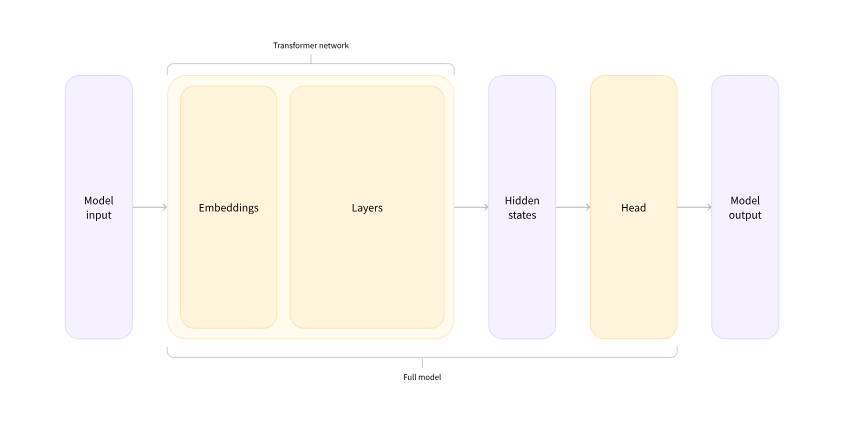

The output of the Transformer model is sent directly to the model head to be processed.

In this diagram, the model is represented by its embeddings layer and the subsequent layers. The embeddings layer converts each input ID in the tokenized input into a vector that represents the associated token. The subsequent layers manipulate those vectors using the attention mechanism to produce the final representation of the sentences.

There are many different architectures available in Transformers, with each one designed around tackling a specific task. Here is a non-exhaustive list:

*Model (retrieve the hidden states)
*ForCausalLM
*ForMaskedLM
*ForMultipleChoice
*ForQuestionAnswering
*ForSequenceClassification
*ForTokenClassification
and others
For our example, we will need a model with a sequence classification head (to be able to classify the sentences as positive or negative). So, we won’t actually use the AutoModel class, but AutoModelForSequenceClassification:

In [2]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

output = model(**inputs)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

NameError: name 'inputs' is not defined

Now if we look at the shape of our outputs, the dimensionality will be much lower: the model head takes as input the high-dimensional vectors we saw before, and outputs vectors containing two values (one per label):



In [3]:
print(outputs.logits.shape)

NameError: name 'outputs' is not defined

Since we have just two sentences and two labels, the result we get from our model is of shape 2 x 2.

**Postprocessing the output**

The values we get as output from our model don’t necessarily make sense by themselves. Let’s take a look:

In [ ]:
print(outputs.logits)

Transformers models output the logits, as the loss function for training will generally fuse the last activation function, such as SoftMax, with the actual loss function, such as cross entropy):

In [ ]:
import torch

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
print(predictions)